# XGBoost
Training XGBoost on the preprocessed and cleaned up features.

In [1]:
from utils.preprocessing import ExtendedPreprocessPipeline, FeaturePreprocessPipeline
from utils.learn import target_encode
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from tqdm import tqdm
from utils.preprocessing import preprocess_currency
import xgboost as xgb
from sklearn.metrics import mean_squared_error
from math import sqrt

In [2]:
pd.set_option('display.max_columns', 50)

In [3]:
df_test = ExtendedPreprocessPipeline.run(pd.read_csv('data/sales_ads_test.csv'))
df_train = ExtendedPreprocessPipeline.run(pd.read_csv('data/sales_ads_train.csv'))
df_data = pd.concat((df_train, df_test), ignore_index=True, copy=True).reset_index()
len(df_test), len(df_train)

Log: Date range : 2021-01-04 00:00:00, 2021-12-04 00:00:00
Log: Preprocessing currency did not found `Cena` column. Skipping.
Log: Date range : 2021-01-05 00:00:00, 2021-12-04 00:00:00
Log: Amount of samples with foreign currency  : 165


(72907, 135397)

In [4]:
df_data = FeaturePreprocessPipeline.run(df_data)

In [5]:
# Too extreme outliers make less reliable validation
df_data.drop(index=df_data.index[df_data.Cena > 6_900_000], inplace=True)

In [6]:
# Selected features
cat_features_high_card = ['Marka_pojazdu', 'Model_pojazdu', 'Generacja_pojazdu']
cat_features_low_card = ['Naped', 'Skrzynia_biegow', 'Typ_nadwozia', 'Kolor', 'Liczba_drzwi',
                         'Kraj_pochodzenia', 'Miasto', 'Wojewodztwo']
binary_features = [
    'Stan_binary'
]
num_features=['Przebieg_km', 'Moc_KM', 'Pojemnosc_cm3', 'Rok_produkcji',
              'Count_wyposazenia']
features = num_features + binary_features

# Encode the targets for the
assert np.all(df_test.ID.to_numpy() == df_data.loc[df_data.Cena.isna(), 'ID'].to_numpy()), "General data frame is incorrectly merged."
# Fill the missing brands with their equivalents
print("Maybach is chainged into Rolls-Royce for testing as it does not appear in training.")
df_test.loc[df_test.Marka_pojazdu == 'Maybach', 'Marka_pojazdu'] = 'Rolls-Royce'
print("Brands, which are in test, but not train. They will be set to Nan.")
print(df_test.loc[~np.isin(df_test.Marka_pojazdu, df_train.Marka_pojazdu.unique()), 'Marka_pojazdu'].to_numpy())
df_test.loc[~np.isin(df_test.Marka_pojazdu, df_train.Marka_pojazdu.unique()), 'Marka_pojazdu'] = np.nan

df = df_data.loc[~df_data.Cena.isna()].copy(deep=True).reset_index()
df_submition = df_data.loc[df_data.Cena.isna()].copy(deep=True).reset_index()

Maybach is chainged into Rolls-Royce for testing as it does not appear in training.
Brands, which are in test, but not train. They will be set to Nan.
['MAN' 'NSU' 'Santana' 'Scion' 'Talbot']


## Training
Training XGBoost on K-Fold validation.

In [7]:
##### Split the data into K folds, but preserve price distribution
num_folds = 6
target_column='Cena'
df.sort_values(by=target_column, inplace=True, kind='stable')  # Split randomly using modulo, but having even price distribution
folds_idx = np.arange(len(df))
for i in folds_idx:
    folds_idx[i] = i % num_folds
folds = []
for i in range(num_folds):
    test_mask = folds_idx == i % num_folds
    folds.append((np.argwhere(~test_mask).flatten(), np.argwhere(test_mask).flatten()))
y = df[target_column]

# XGBoost parameters
params = {
    'max_depth': 10,
    'learning_rate': 0.02,
    'subsample': 0.8,
    'colsample_bytree': 0.8,  # Equivalent to rsm
    'min_child_weight': 10,     # Smooth the groups, don't allow luxury cars to overfit
    'random_state': 100,
    'reg_lambda': 10,         # L2 regularization (similar to l2_leaf_reg)
    'objective': 'reg:squarederror',  # 'pseudohubererror'
    'eval_metric': 'rmse',
}

# Cross-validation stats
cv_results = {
    'test-rmse-mean': [],
    'test-rmse-std': [],
    'train-rmse-mean': [],
    'train-rmse-std': []
}

fold_scores = []
hardest_examples = []
models = []
scores = []
best_model = None
best_rmse = 1_000_000
safe_num_of_estimators = 0
for i, (train_idx, test_idx) in enumerate(folds):
    print(f"Fold {i+1}/{num_folds}")

    X_train, y_train = df.iloc[train_idx], y.iloc[train_idx]
    X_test, y_test = df.iloc[test_idx], y.iloc[test_idx]
    
    # Encode the categories
    # and don't expose data information from validation to train (No data leakage)
    X_train, X_test, all_features = target_encode(X_train.copy(deep=True), X_test.copy(deep=True), features,
                                    cat_features_high_card, cat_features_low_card)
    X_train, X_test = X_train[all_features], X_test[all_features]

    # Create DMatrix objects for XGBoost
    dtrain = xgb.DMatrix(X_train.to_numpy(), label=y_train, feature_names=all_features)
    dtest = xgb.DMatrix(X_test.to_numpy(), label=y_test, feature_names=all_features)

    # Train the model
    model = xgb.train(
        params,
        dtrain,
        num_boost_round=15_000,
        evals=[(dtrain, 'train'), (dtest, 'test')],
        early_stopping_rounds=50,
        verbose_eval=100
    )

    # Get predictions
    train_preds = model.predict(dtrain)
    test_preds = model.predict(dtest)

    # Calculate metrics
    train_rmse = sqrt(mean_squared_error(y_train, train_preds))
    test_rmse = sqrt(mean_squared_error(y_test, test_preds))
    
    # Save model if it has the lowest RMSE
    if test_rmse < best_rmse:
        best_rmse = test_rmse
        best_model = model
    safe_num_of_estimators = (safe_num_of_estimators * i + model.best_iteration) / (i + 1)
    
    # Get the examples, which were the hardest to classify
    test_mse = (y_test - test_preds) ** 2
    hardest_args = np.argsort(test_mse)[-5:]
    hardest_validation_examples = X_test.iloc[hardest_args].copy(deep=True)
    hardest_validation_examples.loc[:, 'Prediction'] = test_preds[hardest_args]
    hardest_validation_examples.loc[:, 'Cena'] = y_test.iloc[hardest_args]
    hardest_examples.append(hardest_validation_examples)

    print(f"Fold {i+1} - Train RMSE: {train_rmse:.6f}, Test RMSE: {test_rmse:.6f}")
    fold_scores.append((train_rmse, test_rmse))
    models.append(model)
    scores.append(test_rmse)

# Stats on best model
print(f"Best validation RMSE: {best_rmse:.6f}")
print(f"Average number of estimators: {safe_num_of_estimators}")

# Summarize results
train_scores = [score[0] for score in fold_scores]
test_scores = [score[1] for score in fold_scores]

cv_results['train-rmse-mean'] = np.mean(train_scores)
cv_results['train-rmse-std'] = np.std(train_scores)
cv_results['test-rmse-mean'] = np.mean(test_scores)
cv_results['test-rmse-std'] = np.std(test_scores)

print("\nCross-Validation Results:")
print(f"Train RMSE: {cv_results['train-rmse-mean']:.6f} ± {cv_results['train-rmse-std']:.6f}")
print(f"Test RMSE: {cv_results['test-rmse-mean']:.6f} ± {cv_results['test-rmse-std']:.6f}")

Fold 1/6


100%|██████████| 8/8 [00:00<00:00, 34.83it/s]


[0]	train-rmse:87449.13940	test-rmse:85084.79561
[100]	train-rmse:30207.17392	test-rmse:28051.71928
[200]	train-rmse:22714.89379	test-rmse:23969.91999
[280]	train-rmse:20939.14355	test-rmse:24031.32132
Fold 1 - Train RMSE: 20939.143706, Test RMSE: 24031.321266
Fold 2/6


100%|██████████| 8/8 [00:00<00:00, 35.21it/s]


[0]	train-rmse:87430.46636	test-rmse:85185.75539
[100]	train-rmse:30225.87554	test-rmse:28193.24890
[200]	train-rmse:22796.43103	test-rmse:22951.95790
[300]	train-rmse:20764.51101	test-rmse:22176.96734
[400]	train-rmse:19845.96267	test-rmse:21986.09767
[500]	train-rmse:19285.56549	test-rmse:21837.29132
[600]	train-rmse:18727.63684	test-rmse:21711.40732
[700]	train-rmse:18187.49094	test-rmse:21606.60573
[800]	train-rmse:17724.53849	test-rmse:21512.01744
[900]	train-rmse:17318.21397	test-rmse:21453.33987
[1000]	train-rmse:16917.85314	test-rmse:21414.86301
[1092]	train-rmse:16585.55472	test-rmse:21377.38587
Fold 2 - Train RMSE: 16582.200003, Test RMSE: 21378.445473
Fold 3/6


...

[0]	train-rmse:87313.82366	test-rmse:85743.34422
[100]	train-rmse:30196.64399	test-rmse:28807.16521
[200]	train-rmse:22991.03840	test-rmse:23652.70816
[300]	train-rmse:21107.30560	test-rmse:23450.34917
[305]	train-rmse:21045.08461	test-rmse:23439.43834
Fold 4 - Train RMSE: 21045.084615, Test RMSE: 23439.438390
Fold 5/6


100%|██████████| 8/8 [00:00<00:00, 34.73it/s]


[0]	train-rmse:87225.97308	test-rmse:86222.83516
[100]	train-rmse:29761.80076	test-rmse:32358.51967
[200]	train-rmse:22433.22954	test-rmse:27015.15610
[300]	train-rmse:20407.53959	test-rmse:25707.75462
[400]	train-rmse:19445.56384	test-rmse:25186.25673
[500]	train-rmse:18818.14567	test-rmse:25055.20833
[600]	train-rmse:18245.69972	test-rmse:24897.79045
[700]	train-rmse:17787.96977	test-rmse:24766.91596
[800]	train-rmse:17349.83415	test-rmse:24654.39941
[900]	train-rmse:16968.55168	test-rmse:24601.29833
[1000]	train-rmse:16591.39400	test-rmse:24531.41446
[1100]	train-rmse:16231.93622	test-rmse:24475.11582
[1132]	train-rmse:16093.67100	test-rmse:24456.80110
Fold 5 - Train RMSE: 16093.671101, Test RMSE: 24456.800950
Fold 6/6


100%|██████████| 8/8 [00:00<00:00, 34.00it/s]


[0]	train-rmse:85538.27323	test-rmse:94307.89703
[100]	train-rmse:26876.37210	test-rmse:44366.23003
[200]	train-rmse:18880.03253	test-rmse:39643.97338
[300]	train-rmse:16587.73395	test-rmse:38844.75553
[400]	train-rmse:15570.52619	test-rmse:38794.80390
[425]	train-rmse:15388.47752	test-rmse:38794.44063
Fold 6 - Train RMSE: 15379.274533, Test RMSE: 38798.321931
Best validation RMSE: 21378.445473
Average number of estimators: 639.0

Cross-Validation Results:
Train RMSE: 17887.345339 ± 2267.857473
Test RMSE: 25862.979357 ± 5865.448521


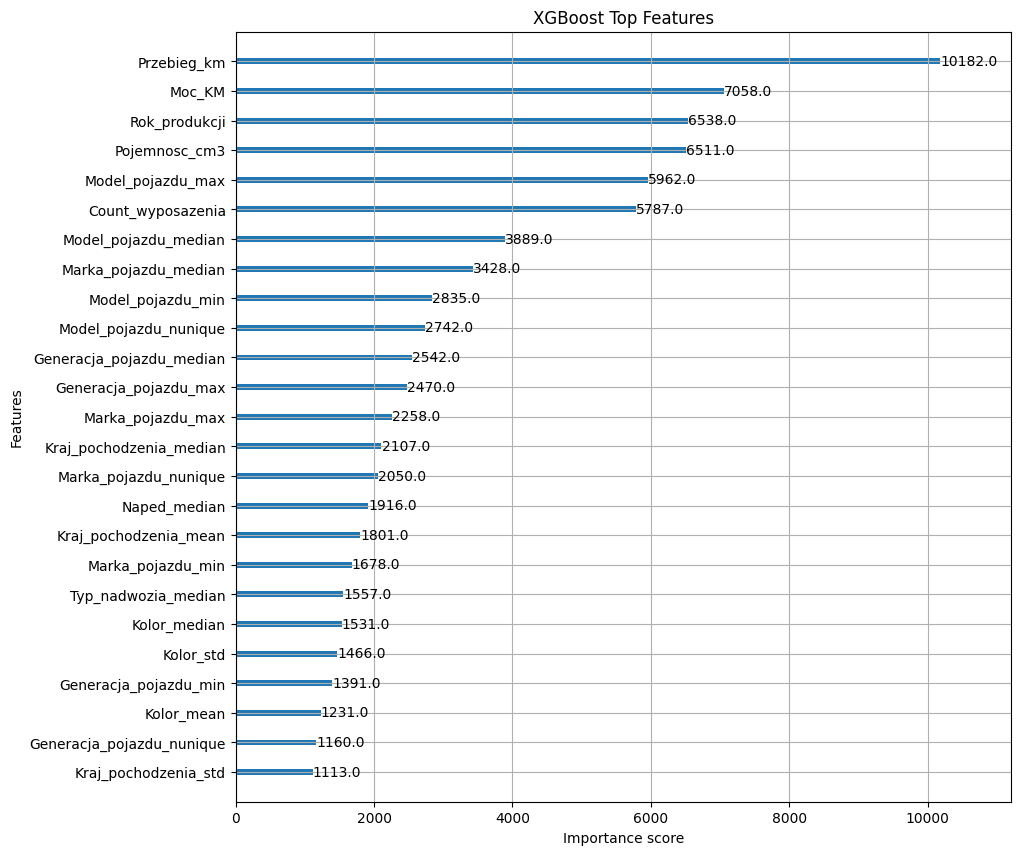

In [8]:
fig, ax = plt.subplots(figsize=(10, 10))
xgb.plot_importance(
    model,
    ax=ax,
    max_num_features=25,
    importance_type="weight", # 'gain', 'cover', 'total_gain', 'total_cover'
)
plt.title("XGBoost Top Features")
plt.show()

Finally, the ensemble of folded models, can be used to predict the final outcome. Nonetheless, it may also propagate
individual models errors. Theoretically, it should be less risky option compared to retraining model on whole dataset,
but also provide less gain as none of the models could see all the relations in the data. Lastly, the target encoding
will change a little bit for it, which introduces a minor risk.

In [9]:
weights = np.array(scores) / np.sum(scores)
def ensemble_predict(data):
    prediction = 0
    for weight, model in tqdm(zip(weights, models), desc="Predicting", total=(len(models))):
        prediction += weight * model.predict(data)
    return prediction

The ensemble can be also used on the final test set.

In [10]:
X_train, X_submition, all_features = target_encode(df.copy(deep=True), df_submition.copy(deep=True), features, cat_features_high_card, cat_features_low_card)
X_train, X_submition = X_train[all_features], X_submition[all_features]
dsub = xgb.DMatrix(X_submition.to_numpy(), feature_names=all_features)
predictions = ensemble_predict(dsub)

Predicting: 100%|██████████| 6/6 [00:02<00:00,  2.90it/s]


## Train the final model
Traininig the final model is performed on the whole dataset to maximise the gain from the data. In such case one have
to be extra careful about overfitting.

In [16]:
# Create very small validation set for final training early stopping
modulo = 1000
df.sort_values(by=target_column, inplace=True, kind='stable')  # Split randomly using modulo, but having even price distribution

test_mask = np.arange(len(df)) % modulo == 0
train_idx, test_idx = np.argwhere(~test_mask).flatten(), np.argwhere(test_mask).flatten()

y = df[target_column]

X_train, y_train = df.iloc[train_idx], y.iloc[train_idx]
X_test, y_test = df.iloc[test_idx], y.iloc[test_idx]

# Encode the categories
# and don't expose data information from validation to train (No data leakage)
X_train, (X_test, X_submition), all_features = target_encode(X_train.copy(deep=True), [X_test.copy(deep=True), df_submition.copy(deep=True)], features, cat_features_high_card, cat_features_low_card)
X_train, X_test, X_submition = X_train.loc[:, all_features], X_test.loc[:, all_features], X_submition.loc[:, all_features]

# Create DMatrix objects for XGBoost
dtrain = xgb.DMatrix(X_train.to_numpy(), label=y_train, feature_names=all_features)
dtest = xgb.DMatrix(X_test.to_numpy(), label=y_test, feature_names=all_features)
# Train the model
model = xgb.train(
    params,
    dtrain,
    num_boost_round=800,     # To ensure there is no overfitting (based on where model improvement plateaus)
    evals=[(dtrain, 'train'), (dtest, 'test')],
    early_stopping_rounds=50,
    verbose_eval=100
)

# Predict
dsub = xgb.DMatrix(X_submition.to_numpy(), feature_names=all_features)
predictions = model.predict(dsub)
print(f"Maximal prediction value detected : {predictions.max()}")
print(f"Maximal target in train : {y_train.max()}")
print(f"Maximal target in test : {y_test.max()}")

100%|██████████| 8/8 [00:00<00:00, 24.48it/s]

[0]	train-rmse:87031.44416	test-rmse:82211.35817


[100]	train-rmse:29339.39304	test-rmse:26087.17080
[200]	train-rmse:22020.52951	test-rmse:18205.06662
[300]	train-rmse:20062.46073	test-rmse:17348.94852
[400]	train-rmse:19262.38885	test-rmse:17203.57128
[500]	train-rmse:18667.69384	test-rmse:17040.93650
[600]	train-rmse:18189.92815	test-rmse:16873.24957
[700]	train-rmse:17711.33713	test-rmse:16755.61760
[799]	train-rmse:17299.90472	test-rmse:16627.11462
Maximal prediction value detected : 1804737.625
Maximal target in train : 6298670.1
Maximal target in test : 672195.0


In [17]:
model.save_model('submission_model.json')

df_submit = df_test.copy(deep=True)
df_submit['Cena'] = predictions
df_submit = preprocess_currency(df_submit, invert=True)

df_submit.drop(columns=[col for col in df_test.columns if col not in ['ID', 'Cena']], inplace=True)
display(df_submit)
df_submit.to_csv('submission.csv', index=False)

Log: Amount of samples with foreign currency  : 99


,ID,Cena
0,1,208418.375000
1,2,18694.919922
2,3,20205.408203
3,4,100873.765625
4,5,91719.750000
...,...,...
72902,72903,114927.023438
72903,72904,31790.486328
72904,72905,60179.328125
72905,72906,24688.341797


In [13]:
df_test.iloc[np.argsort(predictions)[-2]]

ID                                 56490
Waluta                               PLN
Stan                                 New
Marka_pojazdu                Rolls-Royce
Model_pojazdu                     Wraith
                                ...     
wyp_dvd_player                         1
wyp_heated_windscreen                  0
wyp_adjustable_suspension              1
wyp_sunroof                            0
Wiek_oferty                        219.0
Name: 56489, Length: 92, dtype: object

In [14]:
np.sort(predictions)[-1]

1804737.6

In [15]:
df_submit = df_test.copy(deep=True)
df_submit['Cena'] = predictions
df_submit = preprocess_currency(df_submit, invert=True)

mask = df_submit.Waluta == 'EUR'
print(predictions[mask][:10], df_submit.Cena[mask].to_numpy()[:10])

Log: Amount of samples with foreign currency  : 99


[ 73762.05    92451.336   56414.8     21151.03    77005.07   360492.88
  67707.38   135395.55     7423.2446  33785.46  ] [17153.96438953 21500.31068314 13119.72111192  4918.84402253
 17908.15588663 83835.55232558 15745.90297965 31487.33648256
  1726.33596021  7857.08393895]
